In [2]:
import os
import numpy as np
import h5py
from scipy import signal
from scipy.stats import pearsonr
import seaborn as sns
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import string

# Define path to data:
script_dir = os.path.dirname(os.path.abspath("Figure 1 Data Summary.ipynb"))
parent_dir = os.path.dirname(script_dir)
data_path = (parent_dir + '/dfs/')

In [7]:
# Load questionnaires data file:
Quest_data = pd.read_csv(data_path+'df_questionnaires.csv')
CSHQ_data = pd.read_csv(data_path+'df_cshq_clean.csv')

# Remove participants not in 3nights data:
df_3nights_sub = pd.read_csv(data_path+'SSP_participants_3nights.csv')
    
Quest_data = Quest_data[Quest_data['SPID'].isin(df_3nights_sub['SPID'])]
CSHQ_data = CSHQ_data[CSHQ_data['SPID'].isin(df_3nights_sub['SPID'])]

# Merge dataframes:
Merged_data = Quest_data.merge(CSHQ_data, on='SPID', how='inner')

print(len(Quest_data), len(CSHQ_data))

136 136


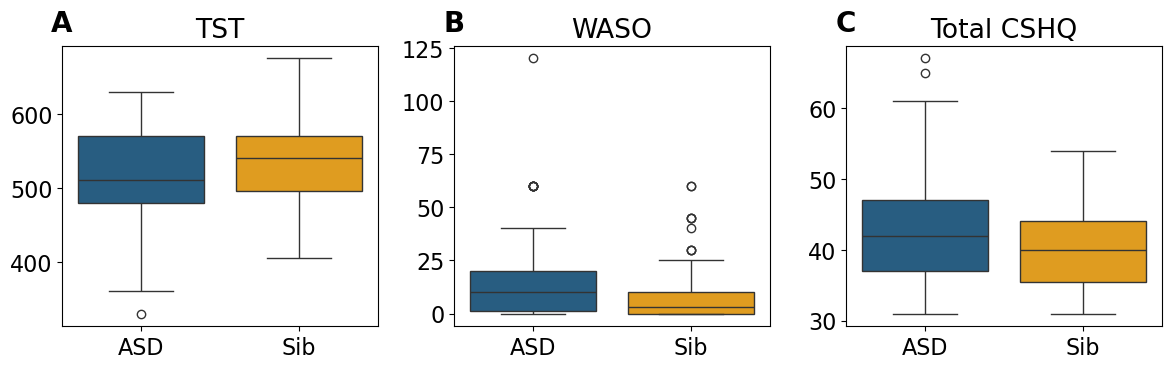

TST:  516.5507246376811 534.3059701492538
WASO:  15.565217391304348 9.671641791044776
Total:  43.14492753623188 40.53731343283582


In [10]:
# Create a new column for the groups
Merged_data['Group'] = Merged_data.apply(lambda row: 'ASD' if row['asd'] else 'Sib', axis=1)

group_order = ['ASD', 'Sib']

# Define a color palette for the groups
hue_colors = {'ASD': '#19609080', 'Sib': '#FFA500'}

# List of metrics and titles
metrics = ['TST', 'WASO', 'cshq_total']
titles = ['TST', 'WASO', 'Total CSHQ']

# Create a grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Flatten the axes for easier iteration
axes = axes.flatten()
# Set global font size for the plot
plt.rcParams.update({'font.size': 16})


# Plot each metric
for i, metric in enumerate(metrics):
    sns.boxplot(x='Group', y=metric, data=Merged_data, order=group_order, ax=axes[i], hue='Group', dodge=False, palette=hue_colors)
    ax = axes[i]
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    # Add panel labels (A, B, C, ...)
    axes[i].text(0, 1.08, string.ascii_uppercase[i], transform=axes[i].transAxes,
                 fontsize=20, fontweight='bold', va='center', ha='center')

# Adjust layout and add more space between rows
plt.subplots_adjust(hspace=0.4)  # Increase vertical space between rows
plt.tight_layout()
plt.show()

# Compute mean TST per group:
asd_tst = Merged_data[Merged_data['asd']==1]['TST'].mean()
sib_tst = Merged_data[Merged_data['asd']==0]['TST'].mean()
# Compute mean WASO per group:
asd_waso = Merged_data[Merged_data['asd']==1]['WASO'].mean()
sib_waso = Merged_data[Merged_data['asd']==0]['WASO'].mean()
# Compute mean total_raw_score per group:
asd_total = Merged_data[Merged_data['asd']==1]['cshq_total'].mean()
sib_total = Merged_data[Merged_data['asd']==0]['cshq_total'].mean()

print('TST: ', asd_tst , sib_tst)
print('WASO: ', asd_waso , sib_waso)
print('Total: ', asd_total , sib_total)


In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Add underscores to all column names in questionnaire dataframe:
Merged_data.columns = [col.replace(" ", "_") for col in Merged_data.columns]

sleep_measures = ['TST', 'WASO', 'cshq_total']

# Initialize a results dictionary to store variance components and ICCs
results = []

for measure in sleep_measures:
    print(f"Analyzing {measure} with ASD, Sex, and Age as fixed effects...")
    
    # Update the formula to include 'asd', 'sex', and 'age' as fixed effects
    formula = f"{measure} ~ asd + sex + age_months"
    
    # Fit the mixed-effects model
    model = smf.mixedlm(formula, Merged_data, groups=Merged_data["Parent_RID"])
    result = model.fit()
    
    # Extract variance components
    random_effects_variance = result.cov_re.iloc[0, 0]  # Between-group variance
    residual_variance = result.scale  # Within-group (residual) variance

    # Calculate the intraclass correlation coefficient (ICC)
    icc = random_effects_variance / (random_effects_variance + residual_variance)

    # Extract fixed-effect estimates and p-values
    asd_effect = result.params['asd[T.True]']
    asd_pvalue = result.pvalues['asd[T.True]']
    sex_effect = result.params['sex[T.Male]']  # Adjust for coding (e.g., if Male is treated as a category)
    sex_pvalue = result.pvalues['sex[T.Male]']
    age_effect = result.params['age_months']
    age_pvalue = result.pvalues['age_months']

    # Store results
    results.append({
        "Measure": measure,
        "Between-Pair Variance": random_effects_variance,
        "Within-Pair Variance": residual_variance,
        "ICC": icc,
        "ASD Effect (Beta)": asd_effect,
        "ASD Effect p-value": asd_pvalue,
        "Sex Effect (Beta)": sex_effect,
        "Sex Effect p-value": sex_pvalue,
        "Age Effect (Beta)": age_effect,
        "Age Effect p-value": age_pvalue
    })

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results)

# Display the results
print(results_df)


Analyzing TST with ASD, Sex, and Age as fixed effects...
Analyzing WASO with ASD, Sex, and Age as fixed effects...
Analyzing cshq_total with ASD, Sex, and Age as fixed effects...
      Measure  Between-Pair Variance  Within-Pair Variance       ICC  \
0         TST             880.115935           2668.204687  0.248037   
1        WASO              69.715589            289.492060  0.194082   
2  cshq_total              11.881134             36.106603  0.247587   

   ASD Effect (Beta)  ASD Effect p-value  Sex Effect (Beta)  \
0         -10.517975            0.291541         -11.177140   
1           5.562077            0.087668           0.667387   
2           3.145208            0.006551          -1.438317   

   Sex Effect p-value  Age Effect (Beta)  Age Effect p-value  
0            0.328295          -0.739703            0.000315  
1            0.856791           0.052823            0.428502  
2            0.279864          -0.015503            0.517284  
